# Retail Sales Forecasting

This notebook presents a complete data science understanding. The project focuses on forecasting weekly sales for a retail chain using historical sales data, store characteristics, and external factors.

## 1. Problem Definition & Business Understanding

- **Objective:** Forecast weekly sales and understand key drivers (e.g., markdown promotions, holidays, economic factors) affecting sales performance.
- **Key Questions:**
  - What factors (store type, markdowns, holidays, economic indicators) drive sales?
  - How do promotional markdowns impact weekly sales?
  - Can we predict future sales accurately using historical data?
- **Success Metrics:** RMSE, MAE, R², and actionable insights for decision making.

### Import necessary Libraries

In [80]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
 
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import LabelEncoder 
 
import scipy.stats as stats 

from sklearn.preprocessing import LabelEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings 
warnings.filterwarnings('ignore') 

## 2. Data Integration

We have three datasets:

1. **features.csv**: Contains environmental and economic data (Temperature, Fuel_Price, CPI, Unemployment, MarkDowns, and IsHoliday).
2. **train.csv**: Contains weekly sales data (Store, Dept, Date, Weekly_Sales, IsHoliday).
3. **stores.csv**: Contains store characteristics (Store, Type, Size).

The datasets are merged using common keys (Store) to produce a final dataset for analysis. In this notebook, we assume the merged dataset is available as `df`.

In [81]:
features = pd.read_csv("features.csv.xls")

In [82]:
features.shape

(8190, 12)

**In Features has 8190 rows and 12 columns**

In [83]:
stores = pd.read_csv("stores.csv.xls")

In [84]:
stores.shape

(45, 3)

**In Store has 45 rows and 3 columns**

In [85]:
train = pd.read_csv("train.csv.xls")

In [86]:
train.shape

(421570, 5)

**In train has 421570 rows and 5 columns**

In [87]:
# Merge train with features on 'Store'
df = pd.merge(train, features, how="inner")

In [88]:
# Merge the result with stores on 'Store'
df = pd.merge(df, stores, on="Store", how="inner")

In [89]:
df.shape

(421570, 16)

**df DataFrame has 421570 and 16 rows in initial phase**

In [90]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


**<pre>Bool Datatype: IsHoliday
Object Dataype: Type
Date type: Date 
Nulls: All MarkDown</pre>**

## 3. Data Cleaning & Preprocessing

- **Convert data types** (e.g., ensure the Date column is datetime).
- **Check for missing values** and handle them appropriately (e.g., fill missing markdowns with 0 if no discount was applied).

In [92]:
# Convert the Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [93]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64

In [94]:
df[['MarkDown1', 'MarkDown2','MarkDown3','MarkDown4','MarkDown5']].isnull().sum().mean()

np.float64(284486.2)

**Around 284486 Weeks are not any MarkDown scheme is apply**

In [95]:
# fill the nulls whit 0
df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']] = df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].fillna(0)

In [96]:
df.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64

In [97]:
df = df.loc[df['Weekly_Sales'] > 0]

## 4. Exploratory Data Analysis (EDA)
We perform univariate, bivariate, and multivariate analyses along with computing central tendency, dispersion, skewness, kurtosis, covariance, and correlation.

In [98]:
num_columns_means = df.select_dtypes(include=np.number).mean()
num_columns_means

Store               22.195611
Dept                44.241309
Weekly_Sales     16033.114591
Temperature         60.090599
Fuel_Price           3.360890
MarkDown1         2590.323565
MarkDown2          878.905242
MarkDown3          468.845949
MarkDown4         1083.534361
MarkDown5         1662.805002
CPI                171.212496
Unemployment         7.960000
Size            136749.732787
dtype: float64

In [99]:
num_columns_median = df.select_dtypes(include=np.number).median()
num_columns_median

Store               22.000000
Dept                37.000000
Weekly_Sales      7661.700000
Temperature         62.090000
Fuel_Price           3.452000
MarkDown1            0.000000
MarkDown2            0.000000
MarkDown3            0.000000
MarkDown4            0.000000
MarkDown5            0.000000
CPI                182.350989
Unemployment         7.866000
Size            140167.000000
dtype: float64

In [100]:
mode_values = df.mode().iloc[0]
mode_values

Store                          13.0
Dept                              1
Date            2011-12-23 00:00:00
Weekly_Sales                   10.0
IsHoliday                     False
Temperature                   50.43
Fuel_Price                    3.638
MarkDown1                       0.0
MarkDown2                       0.0
MarkDown3                       0.0
MarkDown4                       0.0
MarkDown5                       0.0
CPI                      129.855533
Unemployment                  8.099
Type                              A
Size                        39690.0
Name: 0, dtype: object

In [101]:
df.drop(['Date','Type'], axis=1).skew()

Store            0.077947
Dept             0.359016
Weekly_Sales     3.258942
IsHoliday        3.360255
Temperature     -0.321295
Fuel_Price      -0.104678
MarkDown1        4.730933
MarkDown2       10.649277
MarkDown3       14.908890
MarkDown4        8.075125
MarkDown5        9.952112
CPI              0.084673
Unemployment     1.183789
Size            -0.326689
dtype: float64

In [102]:
df.drop(['Date','Type'], axis=1).kurt()

Store            -1.146698
Dept             -1.216644
Weekly_Sales     21.460793
IsHoliday         9.291355
Temperature      -0.636128
Fuel_Price       -1.185445
MarkDown1        34.912307
MarkDown2       145.568291
MarkDown3       247.647517
MarkDown4        86.188903
MarkDown5       183.080984
CPI              -1.829848
Unemployment      2.729259
Size             -1.206400
dtype: float64

In [103]:
df.drop(['Date','Type'], axis=1).corr()

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
Store,1.000000,0.024258,-0.085117,-0.000522,-0.050230,0.065321,-0.059970,-0.033727,-0.020301,-0.042808,-0.012605,-0.211261,0.208759,-0.182763
Dept,0.024258,1.000000,0.148749,0.000663,0.004727,0.003544,0.001454,0.000435,0.001517,0.001881,0.002766,-0.007178,0.007787,-0.002491
Weekly_Sales,-0.085117,0.148749,1.000000,0.012843,-0.002339,0.000089,0.047249,0.020948,0.038522,0.037470,0.050598,-0.021162,-0.025806,0.244117
IsHoliday,-0.000522,0.000663,0.012843,1.000000,-0.155775,-0.078155,-0.003517,0.207326,0.266731,0.011625,-0.015186,-0.001933,0.010555,0.000797
Temperature,-0.050230,0.004727,-0.002339,-0.155775,1.000000,0.143700,-0.026428,-0.179684,-0.056016,-0.050323,-0.014847,0.182223,0.096768,-0.058413
Fuel_Price,0.065321,0.003544,0.000089,-0.078155,0.143700,1.000000,0.297075,0.029282,0.018646,0.166645,0.215588,-0.164199,-0.033915,0.003632
MarkDown1,-0.059970,0.001454,0.047249,-0.003517,-0.026428,0.297075,1.000000,0.175005,-0.014425,0.838866,0.415271,0.010915,-0.105257,0.169891
MarkDown2,-0.033727,0.000435,0.020948,0.207326,-0.179684,0.029282,0.175005,1.000000,-0.006090,0.113446,0.131847,-0.003694,-0.041497,0.078392
MarkDown3,-0.020301,0.001517,0.038522,0.266731,-0.056016,0.018646,-0.014425,-0.006090,1.000000,-0.012031,0.042542,-0.005959,-0.018078,0.033671
MarkDown4,-0.042808,0.001881,0.037470,0.011625,-0.050323,0.166645,0.838866,0.113446,-0.012031,1.000000,0.303536,-0.002061,-0.076583,0.127415


In [104]:
numerical_columns = df.select_dtypes(include=np.number).columns

In [105]:
# num_cols = len(numerical_columns)
# plt.figure(figsize=(15, 5 * num_cols))
# for i, col in enumerate(numerical_columns, 1):
#     # if col == "Weekly_Sales":
#     #     continue
#     plt.subplot(num_cols, 3, i)
#     plt.boxplot(df[col])
#     plt.title(f'Boxplot of {col}')
#     plt.ylabel('Values')

# plt.tight_layout()
# plt.show()

In [106]:
num_data = df.select_dtypes(include = np.number)
Q1 = num_data.quantile(0.25)
Q3 = num_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

In [107]:
# df = df[(df['Store'] > lower_bound['Store']) & (df['Store'] < upper_bound['Store'])]
# df.reset_index(drop=True, inplace=True)

In [108]:
# sns.boxplot(df['Store'])
# plt.show

In [109]:
# df = df[(df['Dept'] > lower_bound['Dept']) & (df['Dept'] < upper_bound['Dept'])]
# df.reset_index(drop=True, inplace=True)

In [110]:
# df = df[(df['Weekly_Sales'] > lower_bound['Weekly_Sales']) & (df['Weekly_Sales'] < upper_bound['Weekly_Sales'])]
# df.reset_index(drop=True, inplace=True)

In [111]:
# df = df[(df['Temperature'] > lower_bound['Temperature']) & (df['Temperature'] < upper_bound['Temperature'])]
# df.reset_index(drop=True, inplace=True)

In [112]:
# df = df[(df['Fuel_Price'] > lower_bound['Fuel_Price']) & (df['Fuel_Price'] < upper_bound['Fuel_Price'])]
# df.reset_index(drop=True, inplace=True)

In [113]:
# df = df[(df['MarkDown1'] > lower_bound['MarkDown1']) & (df['MarkDown1'] < upper_bound['MarkDown1'])]
# df.reset_index(drop=True, inplace=True)

In [114]:
# df = df[(df['MarkDown2'] > lower_bound['MarkDown2']) & (df['MarkDown2'] < upper_bound['MarkDown2'])]
# df.reset_index(drop=True, inplace=True)

In [115]:
# df = df[(df['MarkDown3'] > lower_bound['MarkDown3']) & (df['MarkDown3'] < upper_bound['MarkDown3'])]
# df.reset_index(drop=True, inplace=True)

In [116]:
# df = df[(df['MarkDown4'] > lower_bound['MarkDown4']) & (df['MarkDown4'] < upper_bound['MarkDown4'])]
# df.reset_index(drop=True, inplace=True)

In [117]:
# df = df[(df['MarkDown5'] > lower_bound['MarkDown5']) & (df['MarkDown5'] < upper_bound['MarkDown5'])]
# df.reset_index(drop=True, inplace=True)

In [118]:
# df = df[(df['CPI'] > lower_bound['CPI']) & (df['CPI'] < upper_bound['CPI'])]
# df.reset_index(drop=True, inplace=True)

In [119]:
# df = df[(df['Unemployment'] > lower_bound['Unemployment']) & (df['Unemployment'] < upper_bound['Unemployment'])]
# df.reset_index(drop=True, inplace=True)

In [120]:
# df = df[(df['Size'] > lower_bound['Size']) & (df['Size'] < upper_bound['Size'])]
# df.reset_index(drop=True, inplace=True)

In [121]:
df['Weekly_Sales']


0         24924.50
1         46039.49
2         41595.55
3         19403.54
4         21827.90
            ...   
421565      508.37
421566      628.10
421567     1061.02
421568      760.01
421569     1076.80
Name: Weekly_Sales, Length: 420212, dtype: float64

In [122]:
# num_cols = len(numerical_columns)
# plt.figure(figsize=(15, 5 * num_cols))
# for i, col in enumerate(numerical_columns, 1):
#     plt.subplot(num_cols, 3, i)
#     plt.boxplot(df[col])
#     plt.title(f'Boxplot of {col}')
#     plt.ylabel('Values')

# plt.tight_layout()
# plt.show()

In [123]:
# plt.figure(figsize=[20,10])
# sns.heatmap(df.drop(['Date','Type'], axis=1).corr(), annot = True)

In [124]:
# # Plot histogram & KDE for Weekly Sales
# plt.figure(figsize=(10, 5))
# sns.histplot(df['Weekly_Sales'], kde=True, color='blue')
# plt.title('Distribution of Weekly Sales')
# plt.xlabel('Weekly Sales')
# plt.ylabel('Frequency')
# plt.show()


In [125]:
# plt.figure(figsize=(12, 5))
# sns.histplot(df['CPI'], bins=50, kde=True)
# plt.title('Distribution of CPI')
# plt.xlabel('CPI')
# plt.ylabel('Frequency')
# plt.show()

In [126]:
# plt.figure(figsize=(12, 5))
# sns.histplot(df['Unemployment'], bins=50, kde=True)
# plt.title('Distribution of Unemployment')
# plt.xlabel('Unemployment Rate')
# plt.ylabel('Frequency')
# plt.show()

In [127]:
# # Bivariate Analysis
# plt.figure(figsize=(12, 6))
# sns.scatterplot(x=df['Temperature'], y=df['Weekly_Sales'])
# plt.title('Weekly Sales vs Temperature')
# plt.xlabel('Temperature')
# plt.ylabel('Weekly Sales')
# plt.show()

In [128]:
# plt.figure(figsize=(6, 4))
# sns.barplot(x="IsHoliday", y="Weekly_Sales", data=df)
# plt.title("Holiday vs. Non-Holiday Sales")
# plt.show()

In [129]:
# plt.figure(figsize=(12, 6))
# sns.scatterplot(x=df['Fuel_Price'], y=df['CPI'])
# plt.title('CPI vs Fuel Price')
# plt.xlabel('Fuel Price')
# plt.ylabel('CPI')
# plt.show()

In [130]:
# plt.figure(figsize=(12, 6))
# sns.scatterplot(x=df['Size'], y=df['Weekly_Sales'])
# plt.title('Store Size vs Weekly Sales')
# plt.xlabel('Store Size')
# plt.ylabel('Weekly Sales')
# plt.show()

In [131]:
# plt.figure(figsize=(8, 6))
# sns.boxplot(x='Type', y='Weekly_Sales', data=df)
# plt.title('Weekly Sales by Store Type')
# plt.show()

In [132]:
#Multivariate

In [133]:
# plt.figure(figsize=(12, 6))
# sns.heatmap(df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].corr(), annot=True)
# plt.title('Correlation Heatmap')
# plt.show()

In [134]:
# sns.pairplot(df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']])
# plt.show()

In [135]:
# sns.heatmap(df[['Weekly_Sales', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].corr(), annot = True)

In [136]:
# sns.lineplot(x=df["MarkDown1"], y=df["MarkDown5"])

In [137]:
# plt.plot(df["MarkDown5"], label='Line 1')
# plt.plot(df["MarkDown1"], label='Line 2')
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# plt.legend()
# plt.show()

In [138]:
# sns.lineplot(x=df["MarkDown1"],y=df["Weekly_Sales"], label='Line 1')
# sns.lineplot(x=df["MarkDown5"],y=df["Weekly_Sales"], label='Line 2')
# plt.show()

In [139]:
# sns.scatterplot(x=df["MarkDown1"], y=df["Weekly_Sales"])
# plt.title("Weekly Sales vs. MarkDown1")
# plt.show()

In [140]:
# df.groupby('Type')[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].mean()

## 5. Encoding, Scaling and VIF

- **Label Encoding:** Used for `IsHoliday` and `Type` since they are categorical.
- **Standard Scaling:** Applied `StandardScaler` to normalize numerical features (`Weekly Sales`, `Temperature`, `Fuel Price`, etc.) to improve ML model performance.
- 
**VIF Calculation:**- Measures multicollinearity among numerical variables.
- High VIF values (>10) indicate strong multicollinearity, requiring feature selection.

In [141]:
# Encoding categorical variables
label_encoder = LabelEncoder()
df['IsHoliday'] = label_encoder.fit_transform(df['IsHoliday'])
df['Type'] = label_encoder.fit_transform(df['Type'])

In [142]:
new_data = df.copy()
new_data

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.00,0.00,0.00,0.00,0.00,211.096358,8.106,0,151315
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.00,0.00,0.00,0.00,0.00,211.242170,8.106,0,151315
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.00,0.00,0.00,0.00,0.00,211.289143,8.106,0,151315
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.00,0.00,0.00,0.00,0.00,211.319643,8.106,0,151315
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.00,0.00,0.00,0.00,0.00,211.350143,8.106,0,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,0,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,1,118221
421566,45,98,2012-10-05,628.10,0,64.89,3.985,5046.74,0.00,18.82,2253.43,2340.01,192.170412,8.667,1,118221
421567,45,98,2012-10-12,1061.02,0,54.47,4.000,1956.28,0.00,7.89,599.32,3990.54,192.327265,8.667,1,118221
421568,45,98,2012-10-19,760.01,0,56.47,3.969,2004.02,0.00,3.18,437.73,1537.49,192.330854,8.667,1,118221


In [143]:
new_data.drop(['MarkDown4', 'MarkDown5'], axis = 1, inplace = True)

<Axes: >

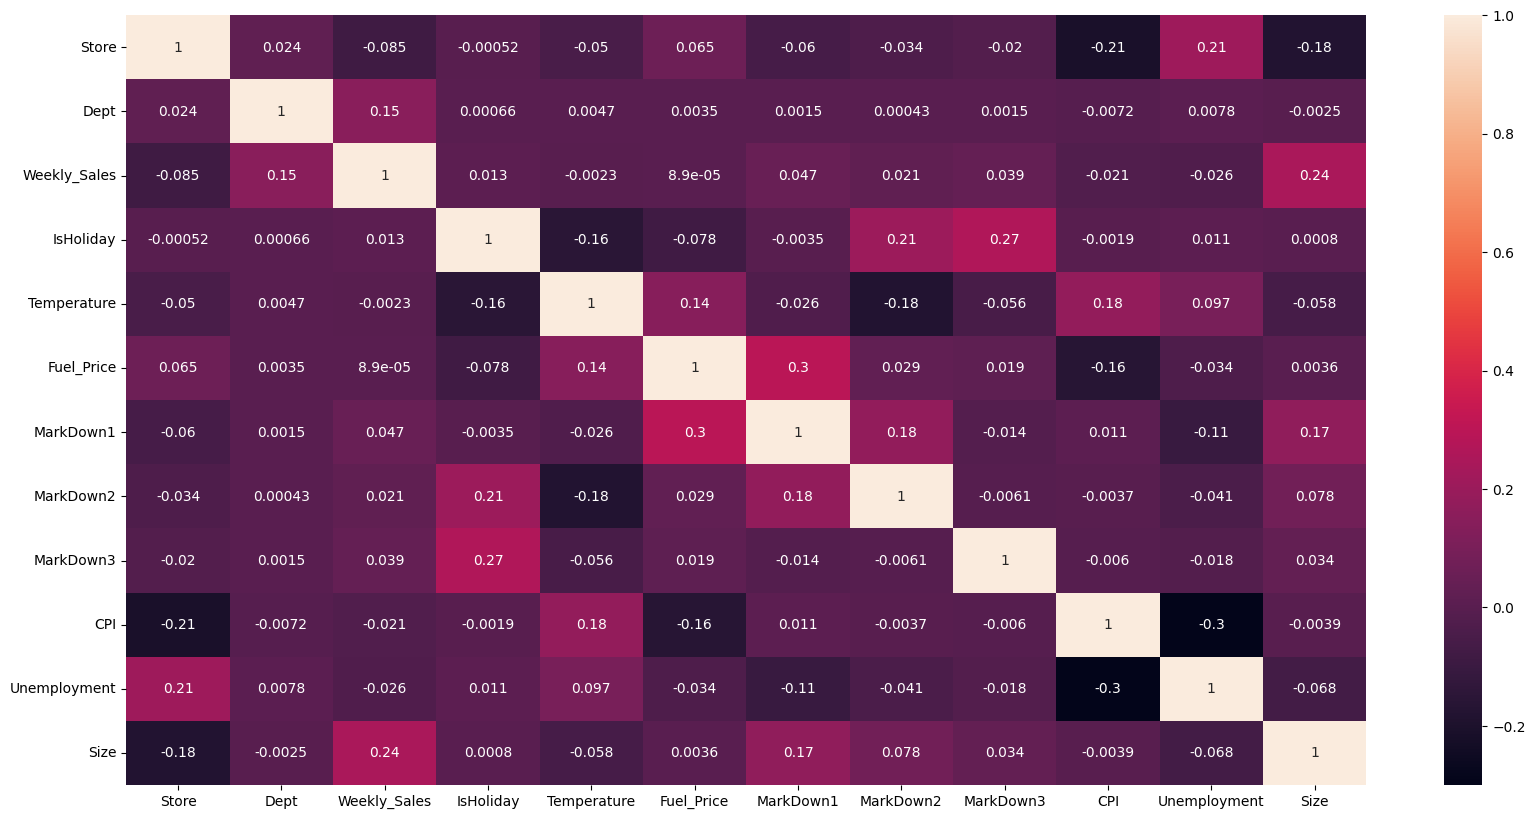

In [144]:
plt.figure(figsize=[20,10])
sns.heatmap(new_data.drop(['Date','Type'], axis=1).corr(), annot = True)

In [145]:
X = new_data.drop(['Weekly_Sales'], axis = 1)
X

,Store,Dept,Date,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,0,42.31,2.572,0.00,0.00,0.00,211.096358,8.106,0,151315
1,1,1,2010-02-12,1,38.51,2.548,0.00,0.00,0.00,211.242170,8.106,0,151315
2,1,1,2010-02-19,0,39.93,2.514,0.00,0.00,0.00,211.289143,8.106,0,151315
3,1,1,2010-02-26,0,46.63,2.561,0.00,0.00,0.00,211.319643,8.106,0,151315
4,1,1,2010-03-05,0,46.50,2.625,0.00,0.00,0.00,211.350143,8.106,0,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,0,64.88,3.997,4556.61,20.64,1.50,192.013558,8.684,1,118221
421566,45,98,2012-10-05,0,64.89,3.985,5046.74,0.00,18.82,192.170412,8.667,1,118221
421567,45,98,2012-10-12,0,54.47,4.000,1956.28,0.00,7.89,192.327265,8.667,1,118221
421568,45,98,2012-10-19,0,56.47,3.969,2004.02,0.00,3.18,192.330854,8.667,1,118221


In [157]:
y = new_data['Weekly_Sales']
y

0         24924.50
1         46039.49
2         41595.55
3         19403.54
4         21827.90
            ...   
421565      508.37
421566      628.10
421567     1061.02
421568      760.01
421569     1076.80
Name: Weekly_Sales, Length: 420212, dtype: float64

In [160]:
scaler = StandardScaler()
# numeric_columns = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size']
# Define target and features
# df[numeric_columns] = scaler.fit_transform(df[numeric_columns])
s_data = scaler.fit_transform(X.drop(['Date'], axis=1))

In [161]:
s_data

array([[-1.65756196, -1.4173397 , -0.27507884, ...,  0.07833123,
        -0.88459568,  0.23880223],
       [-1.65756196, -1.4173397 ,  3.63532138, ...,  0.07833123,
        -0.88459568,  0.23880223],
       [-1.65756196, -1.4173397 , -0.27507884, ...,  0.07833123,
        -0.88459568,  0.23880223],
       ...,
       [ 1.78337339,  1.76207262, -0.27507884, ...,  0.3793168 ,
         0.61599056, -0.30378452],
       [ 1.78337339,  1.76207262, -0.27507884, ...,  0.3793168 ,
         0.61599056, -0.30378452],
       [ 1.78337339,  1.76207262, -0.27507884, ...,  0.3793168 ,
         0.61599056, -0.30378452]])

In [162]:
# # Split the data (80:20 ratio)
X_train, X_test, y_train, y_test = train_test_split(s_data, y, test_size=0.2, random_state=42)

In [163]:
#Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [164]:
# Make predictions on the test set
y_pred = lr_model.predict(X_test)

In [165]:
# Evaluate the model
r2 = r2_score(y_test, y_pred)
r2

0.090491695120541

In [146]:
# # Scaling numerical features
# scaler = StandardScaler()
# # numeric_columns = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size']
# # Define target and features
# target = df['Weekly_Sales']
# features = df.drop(columns=['Weekly_Sales', 'Date', 'IsHoliday', 'Type'])
# # df[numeric_columns] = scaler.fit_transform(df[numeric_columns])
# new_data = scaler.fit_transform(features)

In [147]:
# scaled_data

In [148]:
# features

In [149]:
# vif_data = pd.DataFrame()
# vif_data['Feature'] = features.columns # corrected here
# vif_data['VIF'] = [variance_inflation_factor(features.values, i) for i in range(features.shape[1])] # corrected here
# print(vif_data)

In [150]:
# Compute VIF (Variance Inflation Factor) to detect multicollinearity
# vif_data = pd.DataFrame()
# vif_data['Feature'] = features
# vif_data['VIF'] = [variance_inflation_factor(features.values, i) for i in range(len(features.column))]
# print(vif_data)

## 6. Model Building & Machine Learning

In this section, we build a baseline machine learning model to forecast weekly sales. We will:

- Define the target (`Weekly_Sales`) and features
- Split the data into training and testing sets
- Train a model using Linear Regression
- Evaluate the model performance using RMSE, MAE, and R²

In [151]:
# # Define target and features
# target = df['Weekly_Sales']
# features = df.drop(columns=['Weekly_Sales', 'Date'])

In [152]:
# # Split the data (80:20 ratio)
# X_train, X_test, y_train, y_test = train_test_split(scaled_data, target, test_size=0.2, random_state=42)

In [153]:
# Initialize and train the Linear Regression model
# lr_model = LinearRegression()
# lr_model.fit(X_train, y_train)

In [154]:
# # Make predictions on the test set
# y_pred = lr_model.predict(X_test)

In [155]:
# # Evaluate the model
# r2 = r2_score(y_test, y_pred)
# r2